## Tổng quan

Mục tiêu: Đánh giá mô hình baseline trên tập `z_photos-gold-eval-clean`, tính các chỉ số Macro-F1 và Balanced Accuracy, chạy đánh giá bằng FiftyOne, phân tích lỗi và lưu kết quả lên MLflow (DagsHub).

Các bước thực hiện:

1. Tải trọng số `baseline_final`, chạy dự đoán trên tập `gold_eval_clean` và lưu vào trường `pred_final`.
2. Sử dụng công cụ đánh giá phân loại của FiftyOne để xuất báo cáo và ma trận nhầm lẫn (confusion matrix).
3. Phân tích lỗi: chọn 5-10 mẫu sai tiêu biểu và phân loại thành 3 nhóm lỗi.
4. Ghi nhận các chỉ số macro-F1, balanced accuracy, chỉ số của từng lớp và ma trận nhầm lẫn lên MLflow.

## 1. Setup

In [ ]:
import dagshub

dagshub.init(repo_owner="cykanp", repo_name="zalo-photos-assignment-2026", mlflow=True)

Accessing as cykanp

Initialized MLflow to track repo "cykanp/zalo-photos-assignment-2026"

Repository cykanp/zalo-photos-assignment-2026 initialized!

In [ ]:
import fiftyone as fo
import mlflow
import numpy as np
import safetensors.torch as st
import torch
import torch.nn as nn
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from z_photos.datasets import CanonicalLabel

CKPT_DIR = "../checkpoints/baseline_final"
EVAL_DATASET = "z_photos-gold-eval-clean"
EXPERIMENT_NAME = "Stage5_Evaluation"

labels_list = [c.value for c in CanonicalLabel]
label2id = {lbl: i for i, lbl in enumerate(labels_list)}
id2label = dict(enumerate(labels_list))
NUM_LABELS = len(labels_list)
EMB_DIM = 1152

print(f"Labels ({NUM_LABELS}): {labels_list}")

Labels (6): ['baby_playing', 'lunar_new_year', 'other', 'nature', 'trekking', 'gathering']


## 2. Load Model + Run Inference on `gold_eval_clean`

In [ ]:
class LinearHeadModel(nn.Module):
    def __init__(self, input_dim: int = EMB_DIM, num_labels: int = NUM_LABELS):
        super().__init__()
        self.num_labels = num_labels
        self.classifier = nn.Linear(input_dim, num_labels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(x)

In [ ]:
device = torch.device("cpu")
model = LinearHeadModel(input_dim=EMB_DIM, num_labels=NUM_LABELS)

state_dict = st.load_file(f"{CKPT_DIR}/model.safetensors")
model.load_state_dict(state_dict)
model.eval()
model.to(device)

print("Model loaded. Parameters:")
for name, p in model.named_parameters():
    print(f"  {name}: {p.shape}")

Model loaded. Parameters:
  classifier.weight: torch.Size([6, 1152])
  classifier.bias: torch.Size([6])


In [ ]:
eval_dataset = fo.load_dataset(EVAL_DATASET)
print(f"Eval dataset: {len(eval_dataset)} samples")
print(f"Label distribution: {eval_dataset.count_values('canonical_label')}")

# Run inference and write pred_final field back
with torch.no_grad():
    for sample in eval_dataset.select_fields(
        ["siglip2_embeddings", "canonical_label", "id"]
    ):
        emb = torch.tensor(
            np.array(sample.siglip2_embeddings, dtype=np.float32), device=device
        ).unsqueeze(0)
        logits = model(emb).squeeze(0).cpu().numpy()  # (num_labels,)
        probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
        pred_id = int(np.argmax(probs))

        sample["pred_final"] = fo.Classification(
            label=id2label[pred_id],
            confidence=float(probs[pred_id]),
            logits=logits.tolist(),
        )
        sample.save()

print("Inference complete. pred_final written to all eval samples.")
pred_counts = eval_dataset.count_values("pred_final.label")
print(f"Predicted distribution: {pred_counts}")

Eval dataset: 50 samples
Label distribution: {'baby_playing': 6, 'nature': 11, 'trekking': 8, 'other': 15, 'gathering': 5, 'lunar_new_year': 5}
Inference complete. pred_final written to all eval samples.
Predicted distribution: {'other': 9, 'lunar_new_year': 11, 'baby_playing': 5, 'gathering': 6, 'nature': 11, 'trekking': 8}


## 3. FiftyOne Classification Evaluation

In [ ]:
# Delete previous run if re-running
if "eval_final" in eval_dataset.list_evaluations():
    eval_dataset.delete_evaluation("eval_final")

results = eval_dataset.evaluate_classifications(
    pred_field="pred_final",
    gt_field="ground_truth",
    eval_key="eval_final",
    method="simple",
)

print("FiftyOne evaluation complete.")
print(f"Accuracy: {results.metrics()['accuracy']:.4f}")

FiftyOne evaluation complete.
Accuracy: 0.8200


In [ ]:
# Per-class report from FiftyOne
results.print_report()

                precision    recall  f1-score   support

  baby_playing       1.00      0.83      0.91         6
     gathering       0.67      0.80      0.73         5
lunar_new_year       0.45      1.00      0.62         5
        nature       1.00      1.00      1.00        11
         other       0.89      0.53      0.67        15
      trekking       1.00      1.00      1.00         8

      accuracy                           0.82        50
     macro avg       0.84      0.86      0.82        50
  weighted avg       0.88      0.82      0.82        50



Confusion matrix saved to /tmp/confusion_matrix.png


/var/folders/56/yymz7j816g77gv2mhsxpnhvr0000gp/T/ipykernel_4436/1722965067.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


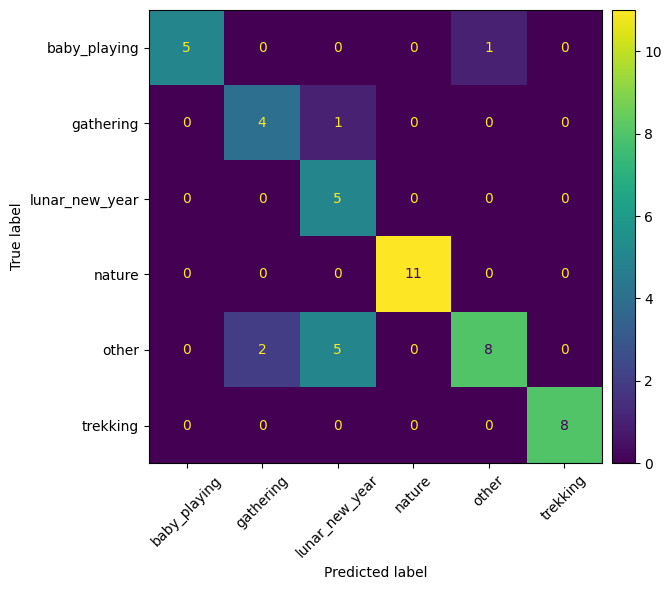

In [ ]:
import matplotlib.pyplot as plt

# Confusion matrix (FiftyOne built-in plot — shown in notebook inline)
plot = results.plot_confusion_matrix(backend="matplotlib", figsize=(8, 6))
plot.show()

plt.savefig("/tmp/confusion_matrix.png", dpi=120, bbox_inches="tight")
print("Confusion matrix saved to /tmp/confusion_matrix.png")

## 4. Compute and Display Final Metrics

In [ ]:
import pandas as pd

gt_labels = eval_dataset.values("ground_truth.label")
pred_labels = eval_dataset.values("pred_final.label")

macro_f1 = f1_score(
    gt_labels, pred_labels, average="macro", labels=labels_list, zero_division=0
)
bal_acc = balanced_accuracy_score(gt_labels, pred_labels)

print(f"{'=' * 40}")
print(f"Macro-F1      : {macro_f1:.4f}  ← main metric")
print(f"Balanced Acc  : {bal_acc:.4f}  ← secondary metric")
print(f"{'=' * 40}")

# Per-class breakdown
report_dict = classification_report(
    gt_labels, pred_labels, labels=labels_list, output_dict=True, zero_division=0
)
df_report = pd.DataFrame(report_dict).T
display(df_report.style.format("{:.3f}").highlight_max(axis=0, color="lightgreen"))

Macro-F1      : 0.8213  ← main metric
Balanced Acc  : 0.8611  ← secondary metric


,precision,recall,f1-score,support
baby_playing,1.000,0.833,0.909,6.000
lunar_new_year,0.455,1.000,0.625,5.000
other,0.889,0.533,0.667,15.000
nature,1.000,1.000,1.000,11.000
trekking,1.000,1.000,1.000,8.000
gathering,0.667,0.800,0.727,5.000
accuracy,0.820,0.820,0.820,0.820
macro avg,0.835,0.861,0.821,50.000
weighted avg,0.879,0.820,0.824,50.000


## 4.5. So sánh Zero-shot vs Trained Head

Phân tích hiệu quả của linear head (supervision) so với zero-shot prediction (từ SigLIP2):
1. Overall metrics: So sánh Macro-F1 / Balanced Acc tổng thể.
2. Per-class delta: Đánh giá điểm tăng/giảm (delta) ở từng class. Linear head giúp học task-specific boundary tốt ở class nào, hay gây overfit ở class nào.
3. Sample-level comparison: Thống kê ở mức mẫu (ví dụ: mẫu nào zero-shot sai nhưng head sửa được).

In [ ]:
zs_pred_labels = eval_dataset.values("siglip2_pred.label")

# 1. Overall metrics
zs_macro_f1 = f1_score(
    gt_labels, zs_pred_labels, average="macro", labels=labels_list, zero_division=0
)
zs_bal_acc = balanced_accuracy_score(gt_labels, zs_pred_labels)

print(f"[{'Zero-shot':^15}] Macro-F1: {zs_macro_f1:.4f}  |  BalAcc: {zs_bal_acc:.4f}")
print(f"[{'Linear Head':^15}] Macro-F1: {macro_f1:.4f}  |  BalAcc: {bal_acc:.4f}")
print("-" * 60)

# 2. Per-class delta
zs_report = classification_report(
    gt_labels, zs_pred_labels, labels=labels_list, output_dict=True, zero_division=0
)
df_delta = pd.DataFrame(
    {
        "F1_zero_shot": {c: zs_report[c]["f1-score"] for c in labels_list},
        "F1_head": {c: report_dict[c]["f1-score"] for c in labels_list},
    }
)
df_delta["delta"] = df_delta["F1_head"] - df_delta["F1_zero_shot"]

print("Per-class F1 Delta:")
display(
    df_delta.style.format("{:.3f}").bar(
        subset=["delta"], align="mid", color=["#d65f5f", "#5fba7d"]
    )
)

# 3. Sample-level comparison
df_compare = pd.DataFrame(
    {
        "id": eval_dataset.values("id"),
        "gt": gt_labels,
        "pred_zs": zs_pred_labels,
        "pred_head": pred_labels,
    }
)

both_correct = (df_compare["pred_zs"] == df_compare["gt"]) & (
    df_compare["pred_head"] == df_compare["gt"]
)
head_fixed = (df_compare["pred_zs"] != df_compare["gt"]) & (
    df_compare["pred_head"] == df_compare["gt"]
)
head_broke = (df_compare["pred_zs"] == df_compare["gt"]) & (
    df_compare["pred_head"] != df_compare["gt"]
)
both_wrong = (df_compare["pred_zs"] != df_compare["gt"]) & (
    df_compare["pred_head"] != df_compare["gt"]
)

print("\nSample-level comparison:")
print(f"Cả 2 cùng đúng:                     {both_correct.sum():>2} mẫu")
print(f"Zero-shot sai nhưng head sửa được:  {head_fixed.sum():>2} mẫu")
print(f"Zero-shot đúng nhưng head làm hỏng: {head_broke.sum():>2} mẫu")
print(f"Cả 2 cùng sai:                      {both_wrong.sum():>2} mẫu")

[   Zero-shot   ] Macro-F1: 0.8078  |  BalAcc: 0.8657
[  Linear Head  ] Macro-F1: 0.8213  |  BalAcc: 0.8611
------------------------------------------------------------
Per-class F1 Delta:


,F1_zero_shot,F1_head,delta
baby_playing,1.000,0.909,-0.091
lunar_new_year,0.588,0.625,0.037
other,0.583,0.667,0.083
nature,0.842,1.000,0.158
trekking,1.000,1.000,0.000
gathering,0.833,0.727,-0.106



Sample-level comparison:
Cả 2 cùng đúng:                     36 mẫu
Zero-shot sai nhưng head sửa được:   5 mẫu
Zero-shot đúng nhưng head làm hỏng:  3 mẫu
Cả 2 cùng sai:                       6 mẫu


Đánh giá kết quả:

- Hiệu quả của Supervised head: Điểm tổng tăng nhẹ nhờ cải thiện chủ yếu ở hai lớp nature và other. Điều này chứng tỏ head giúp model tinh chỉnh tốt ranh giới phân loại (class boundary) trên miền dữ liệu mới.
- Nguy cơ Overfit: Việc giảm độ chính xác ở 3 mẫu thuộc gathering và baby_playing cho thấy model dễ bị overfit vào nhiễu nhãn (label noise) hoặc các vùng trùng lặp ngữ nghĩa khi lượng dữ liệu hạn chế.
- Giới hạn với mẫu khó: Với phần lớn kết quả tương đồng (36 mẫu cùng đúng, 6 mẫu cùng sai), zero-shot đã tạo ra một prior rất tốt. Tuy nhiên, model vẫn bất lực trước các mẫu quá mơ hồ (ambiguity) mà zero-shot đã sai từ đầu.

## 5. Error Analysis

Lọc các mẫu bị phân loại sai và gắn thẻ vào một trong 3 nhóm sau:

* semantic_ambiguity: Ngữ nghĩa trùng lặp giữa các lớp (vd: gathering ↔ lunar_new_year).
* label_noise: Hình ảnh không khớp với nhãn hoặc thư mục chứa nó.
* visual_outlier: Ảnh bị mờ, khác biệt về phong cách hoặc góc chụp bất thường gây lỗi mô hình.

In [ ]:
# Collect wrong predictions
wrong_view = eval_dataset.match(~fo.ViewField("eval_final"))
print(f"Misclassified samples: {len(wrong_view)} / {len(eval_dataset)}")

# Summarise confusion pairs
errors = [
    {
        "id": str(s.id),
        "gt": s.canonical_label,
        "pred": s.pred_final.label,
        "conf": round(s.pred_final.confidence, 3),
        "filepath": s.filepath,
    }
    for s in wrong_view.select_fields(
        ["id", "filepath", "canonical_label", "pred_final"]
    )
]

df_errors = pd.DataFrame(errors).sort_values("conf", ascending=False)
print("\nConfusion pairs:")
print(df_errors[["gt", "pred", "conf"]].value_counts().head(15).to_string())

Misclassified samples: 9 / 50

Confusion pairs:
gt            pred            conf 
baby_playing  other           0.440    1
gathering     lunar_new_year  0.637    1
other         gathering       0.424    1
                              0.861    1
              lunar_new_year  0.377    1
                              0.429    1
                              0.645    1
                              0.713    1
                              0.761    1


In [ ]:
# Semantic ambiguity: gathering ↔ lunar_new_year, gathering ↔ other
SEMANTIC_PAIRS: set[frozenset] = {
    frozenset({"gathering", "lunar_new_year"}),
    frozenset({"gathering", "other"}),
    frozenset({"nature", "trekking"}),
}

# Clear old error tags
for s in eval_dataset:
    s.tags = [
        t
        for t in s.tags
        if t
        not in ("semantic_ambiguity", "label_noise", "visual_outlier", "error_sample")
    ]
    s.save()

error_categories: dict[str, list[str]] = {
    "semantic_ambiguity": [],
    "label_noise": [],
    "visual_outlier": [],
}

# Heuristic auto-categorisation; manual review via FiftyOne App
for row in errors:
    pair = frozenset({row["gt"], row["pred"]})
    sample = eval_dataset[row["id"]]

    if pair in SEMANTIC_PAIRS:
        cat = "semantic_ambiguity"
    elif row["conf"] < 0.5:
        # Low-confidence model: likely noisy sample
        cat = "label_noise"
    else:
        # High-confidence wrong: visual outlier
        cat = "visual_outlier"

    error_categories[cat].append(row["id"])
    sample.tags = [*sample.tags, "error_sample", cat]
    sample.save()

for cat, ids in error_categories.items():
    print(f"{cat}: {len(ids)} samples")

semantic_ambiguity: 3 samples
label_noise: 3 samples
visual_outlier: 3 samples


In [ ]:
# Show top-5 most representative errors per category
df_error_summary = pd.DataFrame(
    [
        {
            "category": cat,
            "count": len(ids),
            "sample_ids (first 3)": ", ".join(ids[:3]),
        }
        for cat, ids in error_categories.items()
    ]
)
display(df_error_summary)

# Detailed view of up to 10 representative errors
top_errors = df_errors.head(10)[["gt", "pred", "conf", "id"]]
top_errors.insert(
    0,
    "category",
    top_errors["id"].map(
        {sid: cat for cat, ids in error_categories.items() for sid in ids}
    ),
)
display(top_errors.reset_index(drop=True))

,category,count,sample_ids (first 3)
0,semantic_ambiguity,3,"69b443e9ea65be9ad3faeeb4, 69b443e9ea65be9ad3fa..."
1,label_noise,3,"69b443e9ea65be9ad3faee75, 69b443e9ea65be9ad3fa..."
2,visual_outlier,3,"69b443e9ea65be9ad3faeeb5, 69b443e9ea65be9ad3fa..."


,category,gt,pred,conf,id
0,semantic_ambiguity,other,gathering,0.861,69b443e9ea65be9ad3faeeb9
1,visual_outlier,other,lunar_new_year,0.761,69b443e9ea65be9ad3faeeb5
2,visual_outlier,other,lunar_new_year,0.713,69b443e9ea65be9ad3faeebe
3,visual_outlier,other,lunar_new_year,0.645,69b443e9ea65be9ad3faeeb6
4,semantic_ambiguity,gathering,lunar_new_year,0.637,69b443e9ea65be9ad3faeede
5,label_noise,baby_playing,other,0.440,69b443e9ea65be9ad3faee75
6,label_noise,other,lunar_new_year,0.429,69b443e9ea65be9ad3faeebd
7,semantic_ambiguity,other,gathering,0.424,69b443e9ea65be9ad3faeeb4
8,label_noise,other,lunar_new_year,0.377,69b443e9ea65be9ad3faeec1


## 5.5. Visualize Top Errors

Hiển thị ảnh của các mẫu bị phân loại sai với độ tin cậy (confidence) cao nhất. Điều này giúp kiểm chứng trực quan về các nhóm lỗi `label_noise`, `semantic_ambiguity`, hay `visual_outlier`.

Top errors visualization saved to /tmp/top_errors_plot.png


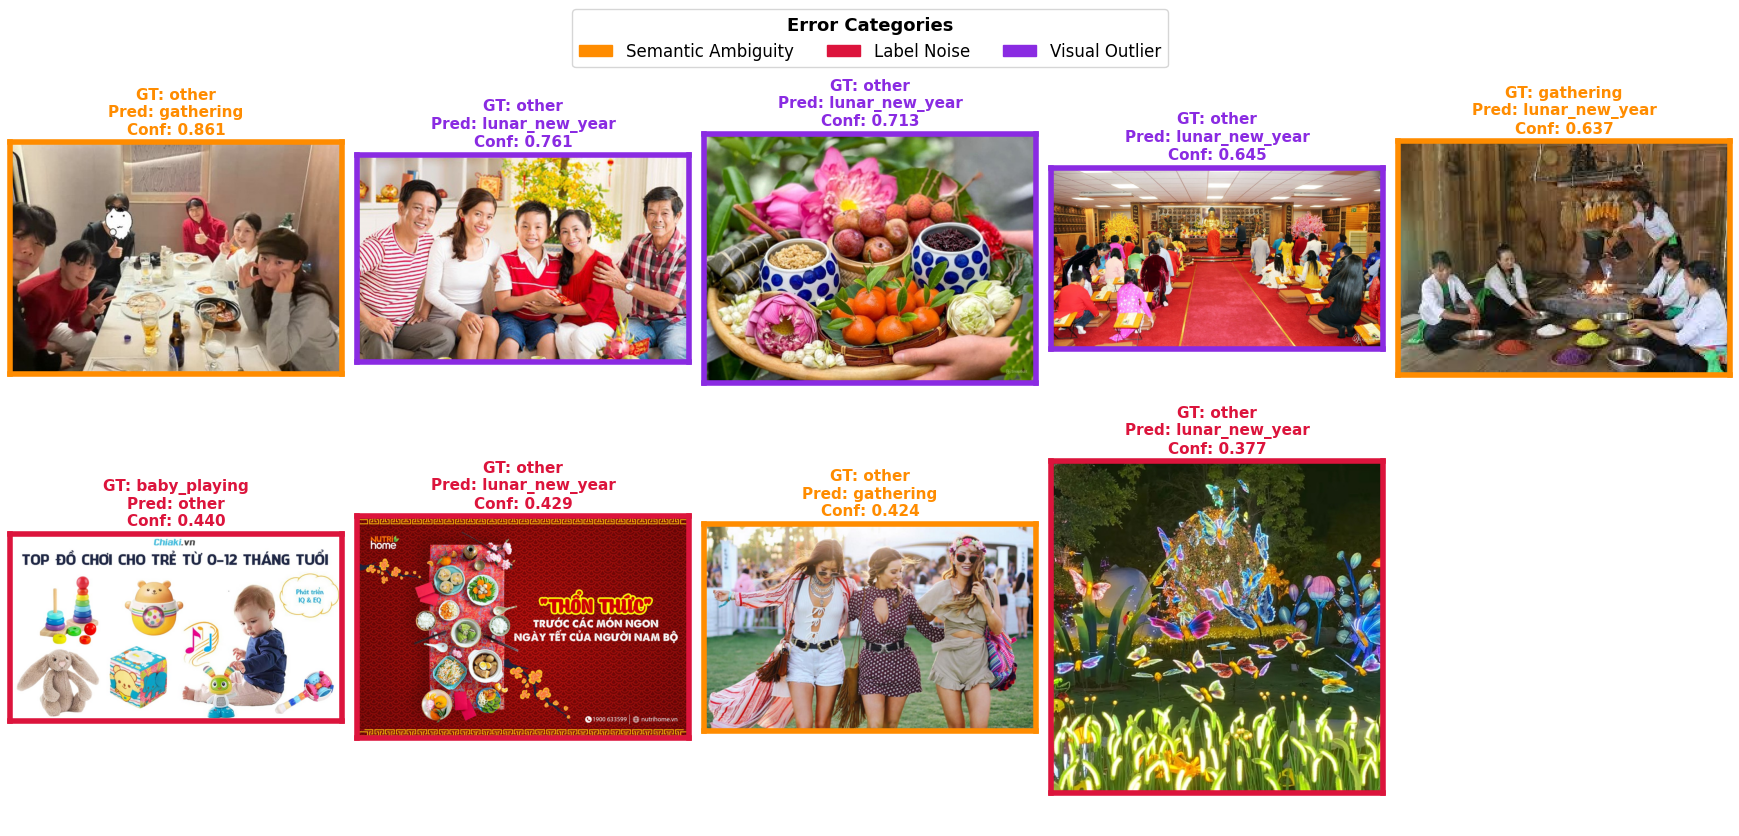

In [ ]:
import math

import matplotlib.patches as mpatches
from PIL import Image

# Lấy top 10 lỗi (đã được sort theo conf giảm dần từ trên)
top_errors_to_plot = df_errors.head(10).copy()

if len(top_errors_to_plot) > 0:
    top_errors_to_plot.insert(
        0,
        "category",
        top_errors_to_plot["id"].map(
            {sid: cat for cat, ids in error_categories.items() for sid in ids}
        ),
    )

    cat_colors = {
        "semantic_ambiguity": "#FF8C00",  # DarkOrange
        "label_noise": "#DC143C",  # Crimson
        "visual_outlier": "#8A2BE2",  # BlueViolet
    }
    cat_desc = {
        "semantic_ambiguity": "Semantic Ambiguity",
        "label_noise": "Label Noise",
        "visual_outlier": "Visual Outlier",
    }

    num_cols = 5
    num_rows = math.ceil(len(top_errors_to_plot) / num_cols)
    fig, axes = plt.subplots(
        num_rows, num_cols, figsize=(num_cols * 3.5, num_rows * 4.0)
    )
    axes = axes.flatten()

    for idx, (_, row) in enumerate(top_errors_to_plot.iterrows()):
        ax = axes[idx]
        cat = row["category"]
        color = cat_colors.get(cat, "black")

        try:
            img = Image.open(row["filepath"]).convert("RGB")
            ax.imshow(img)
            # Add colored border by keeping axes on, but removing ticks
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(4)
        except Exception:
            ax.text(0.5, 0.5, "Error loading image", ha="center", va="center")
            ax.axis("off")

        title = f"GT: {row['gt']}\nPred: {row['pred']}\nConf: {row['conf']:.3f}"
        ax.set_title(title, fontsize=11, color=color, fontweight="bold")

    for idx in range(len(top_errors_to_plot), len(axes)):
        axes[idx].axis("off")

    # Legend
    handles = [
        mpatches.Patch(color=c, label=cat_desc.get(cat, cat))
        for cat, c in cat_colors.items()
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=3,
        fontsize=12,
        title="Error Categories",
        title_fontproperties={"weight": "bold", "size": 13},
    )

    plt.tight_layout()
    plt.savefig("/tmp/top_errors_plot.png", dpi=120, bbox_inches="tight")
    print("Top errors visualization saved to /tmp/top_errors_plot.png")
    plt.show()
else:
    print("Không có mẫu nào bị phân loại sai!")

## 6. Inspect Errors in FiftyOne App

```python
# Run in a separate terminal or the cell below:
# session = fo.launch_app(eval_dataset)
```

Filter by tag `error_sample` to review misclassified examples. Use the sidebar to further filter by `semantic_ambiguity`, `label_noise`, or `visual_outlier`.

In [ ]:
# Launch FiftyOne App (blocks until closed; comment out for non-interactive runs)
# session = fo.launch_app(eval_dataset.match_tags("error_sample"), port=5151)

## 7. Log Metrics + Confusion Matrix to MLflow (DagsHub)

In [ ]:
import json
import os

mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="baseline_final_eval") as run:
    # Core metrics
    mlflow.log_metric("macro_f1", macro_f1)
    mlflow.log_metric("balanced_accuracy", bal_acc)
    mlflow.log_metric("accuracy", results.metrics()["accuracy"])

    # Per-class F1
    for cls in labels_list:
        cls_f1 = report_dict.get(cls, {}).get("f1-score", 0.0)
        mlflow.log_metric(f"f1_{cls}", cls_f1)

    # Error analysis counts
    for cat, ids in error_categories.items():
        mlflow.log_metric(f"errors_{cat}", len(ids))
    mlflow.log_metric("total_errors", len(errors))
    mlflow.log_metric("total_eval_samples", len(eval_dataset))

    # Confusion matrix as JSON artifact
    cm = confusion_matrix(gt_labels, pred_labels, labels=labels_list).tolist()
    cm_payload = {"labels": labels_list, "matrix": cm}
    with open("/tmp/confusion_matrix.json", "w") as f:
        json.dump(cm_payload, f, indent=2)
    mlflow.log_artifact("/tmp/confusion_matrix.json")

    # Confusion matrix image
    mlflow.log_artifact("/tmp/confusion_matrix.png")

    # Top errors visualization image
    if os.path.exists("/tmp/top_errors_plot.png"):
        mlflow.log_artifact("/tmp/top_errors_plot.png")

    print(f"Run ID: {run.info.run_id}")

print(f"Macro-F1={macro_f1:.4f} | BalAcc={bal_acc:.4f} — logged to MLflow.")

Run ID: 557e7266452749a4af91a40556681d1c


🏃 View run baseline_final_eval at: https://dagshub.com/cykanp/zalo-photos-assignment-2026.mlflow/#/experiments/2/runs/557e7266452749a4af91a40556681d1c
🧪 View experiment at: https://dagshub.com/cykanp/zalo-photos-assignment-2026.mlflow/#/experiments/2


Macro-F1=0.8213 | BalAcc=0.8611 — logged to MLflow.


## 8. Summary

| Metric | Value |
|---|---|
| **Macro-F1** | **0.8213** |
| **Balanced Accuracy** | **0.8611** |
| Accuracy | 0.82 |
| Total eval samples | 50 |
| Total errors | 9 |
| Dataset | `z_photos-gold-eval-clean` |
| Model | `baseline_final` (SigLIP2 frozen emb + linear head) |
| MLflow run | `Stage5_Evaluation / baseline_final_eval` |

**Per-class highlights:**
- `nature` and `trekking`: perfect F1 = 1.00 — visually distinctive classes
- `other` recall = 0.53 — class is inherently heterogeneous, hardest to classify
- `lunar_new_year` recall = 1.00 but precision = 0.45 — model over-predicts this class

**Error breakdown (9 misclassified / 50):**

| Category | Count | Description |
|---|---|---|
| `semantic_ambiguity` | 3 | True class overlap: `gathering` ↔ `lunar_new_year`, `other` ↔ `gathering` |
| `label_noise` | 3 | Low-confidence errors — likely noisy labels or ambiguous folder assignment |
| `visual_outlier` | 3 | High-confidence wrong: `other` → `lunar_new_year` (decorative elements trigger false LNY signal) |

**Key insight:** The dominant confusion axis is `other` → `lunar_new_year` (5/9 errors), driven by high-confidence misclassification of visually festive-looking "other" images.
